# Flow Matching Demo

ref: https://zhuanlan.zhihu.com/p/28731517852

In [96]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# 超参数
dim = 2         # 数据维度（2D点）
num_samples = 200
num_steps = 100  # ODE求解步数
lr = 1e-2
epochs = 100000

In [97]:
# 目标分布：正弦曲线上的点（x1坐标）
x1_samples = torch.rand(num_samples, 1) * 4 * torch.pi  # 0到4π
y1_samples = torch.sin(x1_samples)                      # y=sin(x)
target_data = torch.cat([x1_samples, y1_samples], dim=1)

# 噪声分布：高斯噪声（x0坐标）
noise_data = torch.randn(num_samples, dim) * 2

In [98]:
print(x1_samples.shape)
print(y1_samples.shape)
print(target_data.shape)
print(noise_data.shape)

torch.Size([200, 1])
torch.Size([200, 1])
torch.Size([200, 2])
torch.Size([200, 2])


In [99]:
class VectorField(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden_dim = 64
        self.net = nn.Sequential(
            nn.Linear(dim + 1, self.hidden_dim),  # 输入维度: x (2) + t (1) = 3
            nn.ReLU(),
            nn.Linear(self.hidden_dim, dim)
        )
  
    def forward(self, x, t):
        # 直接拼接x和t（t的形状需为(batch_size, 1)）
        return self.net(torch.cat([x, t], dim=1))
        
model = VectorField()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

for epoch in range(epochs):
    # 随机采样噪声点和目标点
    idx = torch.randperm(num_samples)
    x0 = noise_data[idx]  # 起点：噪声
    x1 = target_data[idx] # 终点：正弦曲线

    # 时间t的形状为 (batch_size, 1)
    t = torch.rand(x0.size(0), 1)  # 例如：shape (1000, 1)
  
    # 线性插值生成中间点
    xt = (1 - t) * x0 + t * x1
  
    # 模型预测向量场（直接传入t，无需squeeze）
    vt_pred = model(xt, t)  # t的维度保持不变
  
    # 目标向量场：x1 - x0
    vt_target = x1 - x0
  
    # 损失函数
    loss = torch.mean((vt_pred - vt_target)**2)
  
    # 反向传播
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # print(idx.shape)
    # print(t.shape)
    # print(xt.shape)
    # break
    

tensor([[0.0049, 0.6461]])
tensor([ 4.5778, -0.1948])


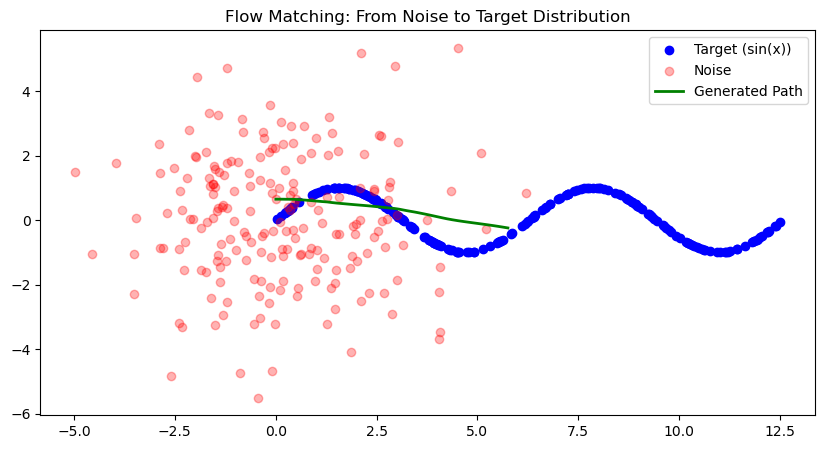

In [100]:
x = noise_data[0:1]  # 初始噪声点
print(x)
trajectory = [x.detach().numpy()]

tag = torch.from_numpy(np.array([1]))
# 数值求解ODE（欧拉法）
t = 0
num_steps = 50
delta_t = 1 / num_steps
with torch.no_grad():
    for i in range(num_steps):
        vt = model(x, torch.tensor([[t]], dtype=torch.float32))
        t += delta_t
        x = x + vt * delta_t  # x(t+Δt) = x(t) + v(t)Δt
        trajectory.append(x.detach().numpy())

trajectory = torch.tensor(trajectory).squeeze()

print(trajectory[-1] / (torch.pi / 10 * 4))

# 绘制向量场和生成轨迹
plt.figure(figsize=(10, 5))
plt.scatter(target_data[:,0], target_data[:,1], c='blue', label='Target (sin(x))')
plt.scatter(noise_data[:,0], noise_data[:,1], c='red', alpha=0.3, label='Noise')
plt.plot(trajectory[:,0], trajectory[:,1], 'g-', linewidth=2, label='Generated Path')
plt.legend()
plt.title("Flow Matching: From Noise to Target Distribution")
plt.show()

## Conditional Flow Matching

In [103]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# 超参数
dim = 2         # 数据维度（2D点）
num_samples = 1000
num_steps = 50  # ODE求解步数
lr = 1e-3
epochs = 5000


# 目标分布：正弦曲线上的点（x1坐标）
x1_samples = torch.rand(num_samples, 1) * 4 * torch.pi  # 0到4π
y1_samples = torch.sin(x1_samples)                      # y=sin(x)
target_data = torch.cat([x1_samples, y1_samples], dim=1)
tags = torch.from_numpy(np.array([[int(x1_samples[i] / (4 * torch.pi / 10.0)),] for i in range(num_samples)]))

# 噪声分布：高斯噪声（x0坐标）
noise_data = torch.randn(num_samples, dim) * 2
print(tags.shape)
print(tags[:5])

torch.Size([1000, 1])
tensor([[8],
        [3],
        [6],
        [3],
        [9]])


tensor([1.4713, 0.7630])


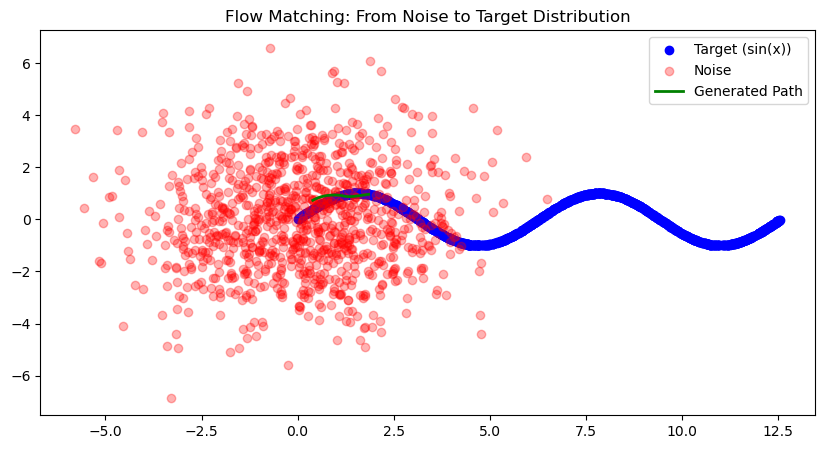

In [101]:
class VectorField(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 2, 64),  # 输入维度: x (2) + t (1) + tag(1) = 4
            nn.ReLU(),
            nn.Linear(64, dim)
        )
  
    def forward(self, x, t, tag):
        # 直接拼接x和t（t的形状需为(batch_size, 1)）
        return self.net(torch.cat([x, t, tag], dim=1))
        #return self.net(torch.cat([x, t], dim=1))
model = VectorField()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

for epoch in range(epochs):
    # 随机采样噪声点和目标点
    idx = torch.randperm(num_samples)
    x0 = noise_data[idx]  # 起点：噪声
    x1 = target_data[idx] # 终点：正弦曲线

    # 时间t的形状为 (batch_size, 1)
    t = torch.rand(x0.size(0), 1)  # 例如：shape (1000, 1)
  
    # 线性插值生成中间点
    xt = (1 - t) * x0 + t * x1
  
    # 模型预测向量场（直接传入t，无需squeeze）
    vt_pred = model(xt, t, tags[idx])  # t的维度保持不变
  
    # 目标向量场：x1 - x0
    vt_target = x1 - x0
  
    # 损失函数
    loss = torch.mean((vt_pred - vt_target)**2)
  
    # 反向传播
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# 从噪声出发，解ODE生成数据
x = noise_data[0:1]  # 初始噪声点
trajectory = [x.detach().numpy()]

tag_num = 1
tag = torch.from_numpy(np.array([tag_num]))

# 数值求解ODE（欧拉法）
t = 0
delta_t = 1 / num_steps
with torch.no_grad():
    for i in range(num_steps):
        vt = model(x, torch.tensor([[t]], dtype=torch.float32), tag.reshape([1,1]))
        t += delta_t
        x = x + vt * delta_t  # x(t+Δt) = x(t) + v(t)Δt
        trajectory.append(x.detach().numpy())

trajectory = torch.tensor(trajectory).squeeze()

print(trajectory[-1] / (torch.pi / 10 * 4))

# 绘制向量场和生成轨迹
plt.figure(figsize=(10, 5))
plt.scatter(target_data[:,0], target_data[:,1], c='blue', label='Target (sin(x))')
plt.scatter(noise_data[:,0], noise_data[:,1], c='red', alpha=0.3, label='Noise')
plt.plot(trajectory[:,0], trajectory[:,1], 'g-', linewidth=2, label='Generated Path')
plt.legend()
plt.title("Flow Matching: From Noise to Target Distribution")
plt.show()